# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('loan_data.csv')

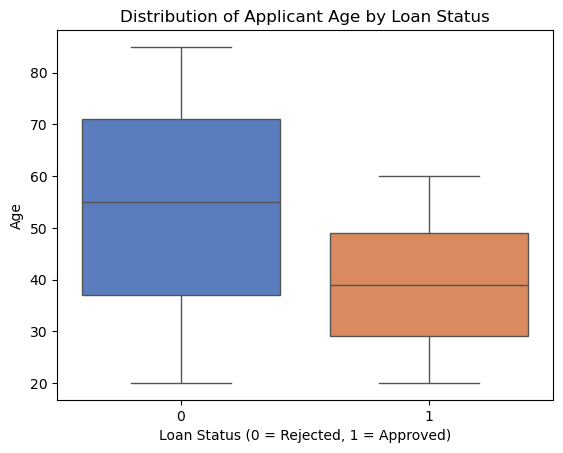

In [3]:
sns.boxplot(x='loan_status', y='person_age', data=df, hue='loan_status', palette='muted', legend=False)
plt.title('Distribution of Applicant Age by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Age')
plt.show()

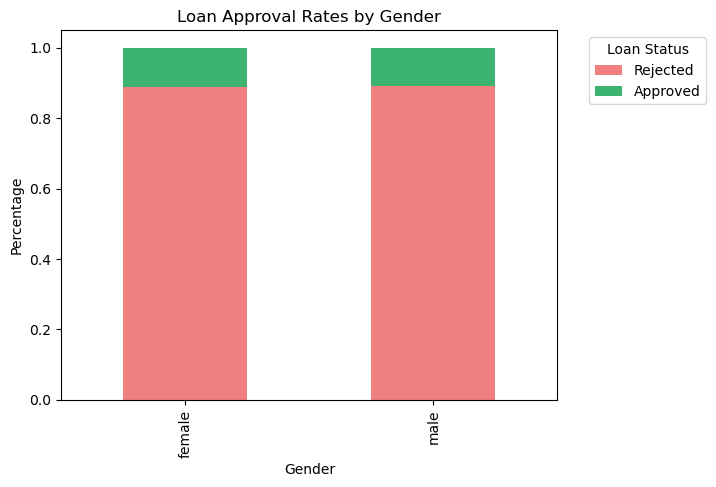

In [4]:
pd.crosstab(df['person_gender'], df['loan_status'], normalize='index').plot(kind='bar', stacked=True, color=['lightcoral', 'mediumseagreen'])
plt.title('Loan Approval Rates by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.legend(['Rejected', 'Approved'], title='Loan Status', bbox_to_anchor=(1.05, 1))
plt.show()

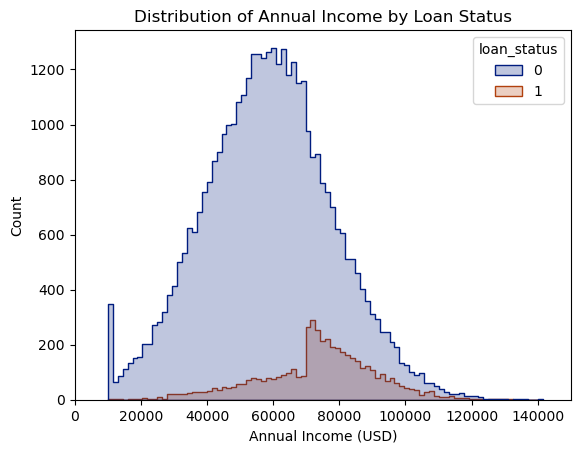

In [5]:
sns.histplot(x='person_income', hue='loan_status', data=df, element='step', palette='dark')
plt.title('Distribution of Annual Income by Loan Status')
plt.xlabel('Annual Income (USD)')
plt.xlim(0, 150000) 
plt.show()

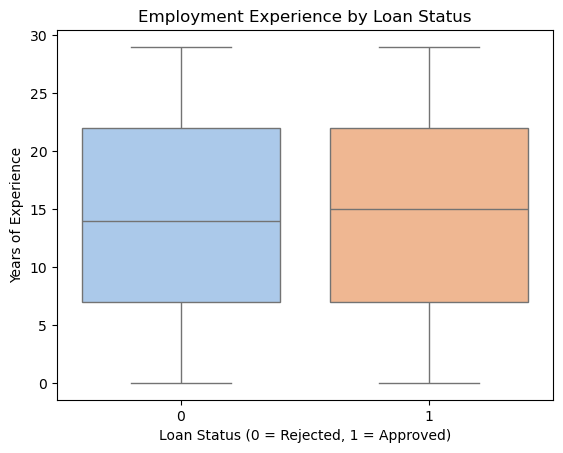

In [6]:
sns.boxplot(x='loan_status', y='person_emp_exp', data=df, hue='loan_status', palette='pastel', legend=False)
plt.title('Employment Experience by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Years of Experience')
plt.show()

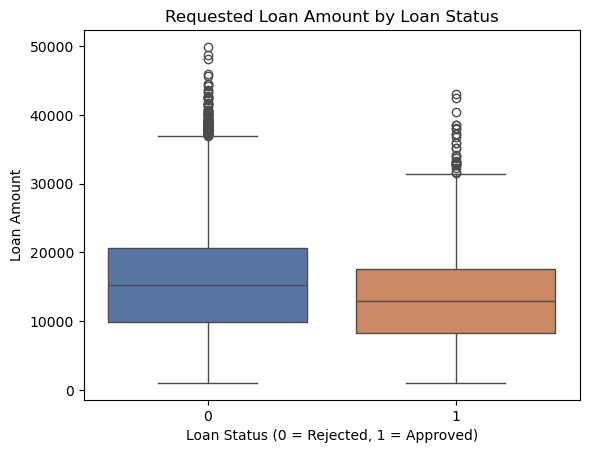

In [7]:
sns.boxplot(x='loan_status', y='loan_amnt', data=df, hue='loan_status', palette='deep', legend=False)
plt.title('Requested Loan Amount by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Loan Amount')
plt.show()

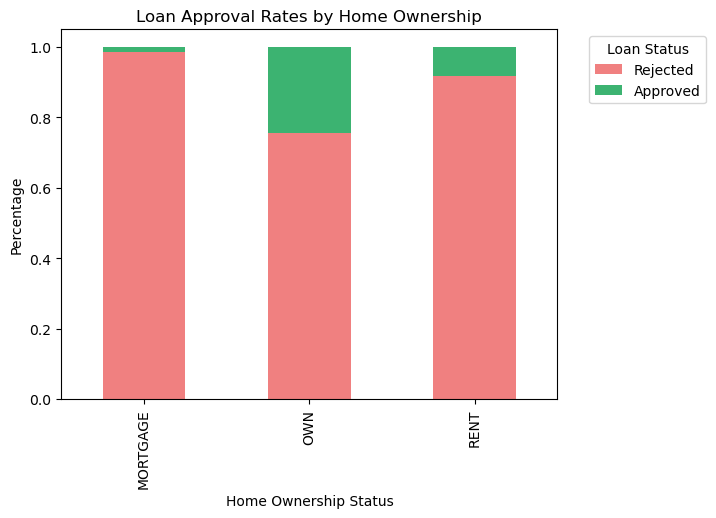

In [8]:
pd.crosstab(df['person_home_ownership'], df['loan_status'], normalize='index').plot(kind='bar', stacked=True, color=['lightcoral', 'mediumseagreen'])
plt.title('Loan Approval Rates by Home Ownership')
plt.xlabel('Home Ownership Status')
plt.ylabel('Percentage')
plt.legend(['Rejected', 'Approved'], title='Loan Status', bbox_to_anchor=(1.05, 1))
plt.show()

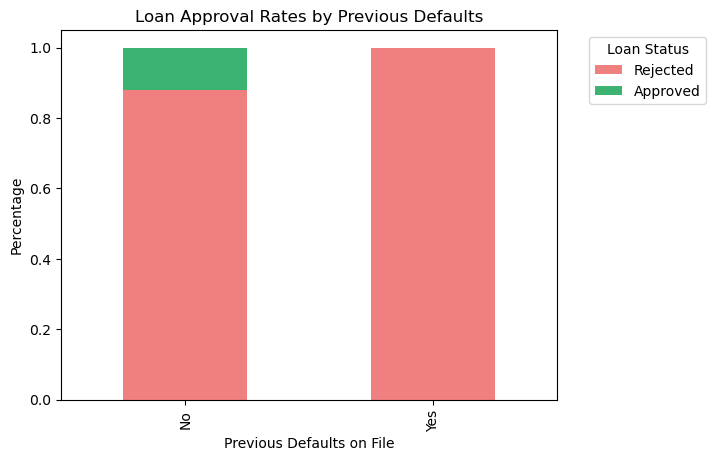

In [9]:
pd.crosstab(df['previous_loan_defaults_on_file'], df['loan_status'], normalize='index').plot(kind='bar', stacked=True, color=['lightcoral', 'mediumseagreen'])
plt.title('Loan Approval Rates by Previous Defaults')
plt.xlabel('Previous Defaults on File')
plt.ylabel('Percentage')
plt.legend(['Rejected', 'Approved'], title='Loan Status', bbox_to_anchor=(1.05, 1))
plt.show()

Data Relationships & Legal Liability Breakdown:

What drives the model? (The Algorithmic Meta)
Looking at the visualizations, the core meta for getting a loan approved revolves entirely around passing a financial "stat check". Features like person_income, person_home_ownership, and previous_loan_defaults_on_file are heavily correlated with loan_status. For example, applicants with a history of previous defaults or significantly lower annual incomes have a massively higher rejection rate. Renters are also rejected at much higher rates than people who own their homes.

What doesn't matter? (The Unrelated Features)
The features that seem completely ignored by the AI's algorithm are person_age and person_gender. The boxplots for age look practically identical across both the approved and rejected statuses (the medians and IQR line up perfectly), meaning being older or younger doesn't shift the outcome. Similarly, the stacked bar chart for gender shows an almost equal 50/50 proportional split of approvals and rejections across different sexes.

Should the company be worried about legal trouble?
Based on this specific dataset, the financial institution should not be sweating a discrimination lawsuit over Age or Sex. The Seaborn visualizations clearly prove that the AI model is not nerfing applicants based on these demographics. Instead, it is making its determinations based on pure financial risk metrics (Income, Experience, and Default History).